In [17]:
import os
from typing import TypedDict
from langgraph.graph import StateGraph, END
from openai import OpenAI
from dotenv import load_dotenv
from openai import AsyncOpenAI
from IPython.display import Image, display



In [18]:
load_dotenv(override=True)

client = OpenAI(base_url=os.getenv("OPENROUTER_BASE_URL"),api_key=os.getenv("OPENROUTER_API_KEY"))


In [19]:
class AgentState(TypedDict):
    input: str
    output: str


In [31]:
# __define-ocg__ simple tools for agent

def calculator(expression: str) -> str:
    try:
        return str(eval(expression))
    except Exception:
        return "Invalid expression"


def run_python(code: str) -> str:
    try:
        varOcg = {}  # required variable name
        exec(code, {}, varOcg)
        return str(varOcg)
    except Exception as e:
        return str(e)


def docs_helper(query: str) -> str:
    docs = {
        "langgraph": "LangGraph is used for building stateful AI workflows.",
        "rag": "RAG = Retrieval Augmented Generation.",
        "api": "API stands for Application Programming Interface."
    }
    q = (query or "").lower().strip()
    if q in docs:
        return docs[q]
    # Strip question prefixes (handles "what is rag" and "what israg")
    for prefix in ("what is ", "what is"):
        if q.startswith(prefix):
            q = q[len(prefix) :].strip()
            break
    if q in docs:
        return docs[q]
    # Match a known topic token in the original question
    words = "".join(c if c.isalnum() else " " for c in (query or "").lower()).split()
    for key in sorted(docs.keys(), key=len, reverse=True):
        if key in words:
            return docs[key]
    return "No docs found"

In [32]:
def llm_node(state: AgentState):
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "You are a helpful developer assistant."},
            {"role": "user", "content": state["input"]}
        ]
    )
    
    return {"output": response.choices[0].message.content}

In [33]:
def router(state: AgentState):
    text = state["input"].lower()

    if "calculate" in text:
        return "calculator"
    elif "run code" in text:
        return "python"
    elif "what is" in text:
        return "docs"
    else:
        return "llm"

In [34]:
def calculator_node(state: AgentState):
    expression = state["input"].replace("calculate", "")
    result = calculator(expression)
    return {"output": result}


def python_node(state: AgentState):
    code = state["input"].replace("run code", "")
    result = run_python(code)
    return {"output": result}


def docs_node(state: AgentState):
    result = docs_helper(state["input"])
    return {"output": result}

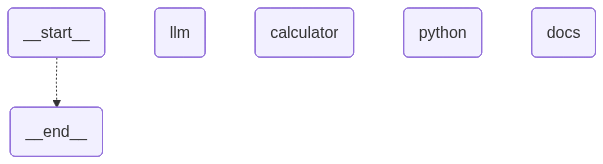

In [28]:
builder = StateGraph(AgentState)

# Add nodes
builder.add_node("llm", llm_node)
builder.add_node("calculator", calculator_node)
builder.add_node("python", python_node)
builder.add_node("docs", docs_node)

# Entry point (router)
builder.set_conditional_entry_point(router)

# Define edges
builder.add_edge("calculator", END)
builder.add_edge("python", END)
builder.add_edge("docs", END)
builder.add_edge("llm", END)

# Compile graph
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:
# Test calculator
result = graph.invoke({"input": "calculate 5 * 10 + 3"})
print(result)


# Test python execution
result = graph.invoke({"input": "run code x = 5\ny = 10\nz = x + y"})
print(result)


# # Test docs
result = graph.invoke({"input": "what is rag"})
print(result)


# Test LLM fallback
result = graph.invoke({"input": "Explain REST APIs"})
print(result)

{'input': 'what is rag', 'output': 'RAG = Retrieval Augmented Generation.'}
